# Módulo 2 — Clase 5: Machine Learning para targeting de programas sociales

**Curso:** Python y Políticas Públicas  
**Nivel:** Avanzado  
**Duración estimada:** 2 horas

---

## Objetivos de la clase

- Comprender el problema de targeting en política social y sus tipos de errores
- Aplicar modelos de machine learning (Regresión Logística y Random Forest) para clasificación de hogares
- Interpretar métricas de clasificación en términos de errores de política pública
- Analizar el trade-off entre errores de inclusión y exclusión mediante el umbral de decisión

---

## 1. El problema de targeting en política social

### ¿Qué es el targeting?

El **targeting** (focalización) es el mecanismo por el cual un programa social identifica y selecciona a sus beneficiarios entre la población elegible. Un buen sistema de targeting logra que los recursos lleguen a quienes más los necesitan, minimizando filtraciones hacia quienes no califican.

### Principales tipos de targeting

| Tipo | Descripción | Ejemplo |  
|------|-------------|---------|  
| **Means-tested** | Verificación directa de ingresos/activos | Asignación Universal por Hijo (AUH) |  
| **Categórico** | Elegibilidad por características observables (edad, sexo) | Jubilación universal para mayores de 65 |  
| **PMT (Proxy Means Test)** | Se estima el nivel socioeconómico a partir de variables proxy (vivienda, educación, activos) | SISBEN en Colombia, Ficha CAS en Chile |
| **Autoselección** | El diseño del programa desincentiva la participación de no-pobres | Programas de workfare |

### Errores de inclusión y exclusión

Ningún sistema de targeting es perfecto. Siempre existen dos tipos de errores:

- **Error de inclusión (Tipo I / Falso Positivo):** Un hogar que **no** es elegible recibe el beneficio. Se filtra el programa hacia la población no-objetivo. Incrementa el costo fiscal.

- **Error de exclusión (Tipo II / Falso Negativo):** Un hogar que **sí** es elegible no recibe el beneficio. Se excluye a quienes más necesitan la intervención. Implica un fallo de equidad.

$$\text{Tasa de inclusión indebida} = \frac{FP}{FP + TN}$$

$$\text{Tasa de exclusión indebida} = \frac{FN}{FN + TP}$$

Existe un **trade-off** inherente entre ambos errores. Al relajar los criterios de elegibilidad, se reducen las exclusiones pero se incrementan las inclusiones indebidas, y viceversa. El umbral óptimo depende de los costos políticos y fiscales de cada tipo de error.

> **Pregunta de reflexión:** ¿Cuándo es más costoso el error de exclusión? ¿Cuándo lo es el de inclusión? Piensen en un programa de salud materno-infantil vs. un subsidio a empresas.

---

## 2. Generación del dataset sintético

Vamos a crear un dataset que replica la estructura de la **Encuesta Permanente de Hogares (EPH)** del INDEC. El dataset tiene 5.000 hogares con las variables más relevantes para un Proxy Means Test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


In [2]:
np.random.seed(42)
n = 5000

# --- Región (NOA, NEA, Cuyo, Pampeana, Patagonia, GBA) ---
regiones = ['GBA', 'Pampeana', 'NOA', 'NEA', 'Cuyo', 'Patagonia']
probs_region = [0.35, 0.25, 0.15, 0.10, 0.08, 0.07]
region = np.random.choice(regiones, n, p=probs_region)

# --- Años de educación del jefe/a de hogar ---
# Correlacionado con región: NOA y NEA tienen menor educación promedio
edu_base = {'GBA': 11, 'Pampeana': 11, 'NOA': 8, 'NEA': 8, 'Cuyo': 10, 'Patagonia': 11}
educacion = np.array([max(0, np.random.normal(edu_base[r], 3.5)) for r in region]).astype(int)
educacion = np.clip(educacion, 0, 20)

# --- Ingreso per cápita del hogar (en pesos, log-normal) ---
# Correlacionado con educación y región
ingreso_mu = 9.5 + 0.12 * educacion + np.where(np.isin(region, ['NOA', 'NEA']), -0.4, 0)
ingreso_pcapita = np.random.lognormal(ingreso_mu, 0.7)

# --- Tenencia de vivienda (0=inquilino/precario, 1=propietario) ---
# Correlacionado con ingreso
prob_propietario = 1 / (1 + np.exp(-(ingreso_pcapita / 50000 - 3)))
propietario = np.random.binomial(1, prob_propietario)

# --- Hacinamiento (personas por cuarto, >=2 es crítico) ---
# Mayor en hogares pobres
hacinamiento_mu = 1.2 - 0.00002 * ingreso_pcapita + np.where(np.isin(region, ['NOA', 'NEA']), 0.3, 0)
hacinamiento = np.clip(np.random.lognormal(np.log(np.clip(hacinamiento_mu, 0.5, 5)), 0.4), 0.5, 6)

# --- Cobertura de salud (0=solo pública, 1=obra social/prepaga) ---
prob_cobertura = 1 / (1 + np.exp(-(ingreso_pcapita / 40000 - 2.5)))
cobertura_salud = np.random.binomial(1, prob_cobertura)

# --- Presencia de menores de 18 en el hogar ---
# Ligeramente más frecuente en hogares con menor ingreso
prob_menores = 0.55 - 0.00001 * ingreso_pcapita
prob_menores = np.clip(prob_menores, 0.2, 0.85)
tiene_menores = np.random.binomial(1, prob_menores)

# --- Empleo informal del jefe/a ---
# Mayor en hogares pobres y con menor educación
prob_informal = 1 / (1 + np.exp(0.0001 * ingreso_pcapita + 0.15 * educacion - 2.0))
empleo_informal = np.random.binomial(1, prob_informal)

# --- Variable objetivo: elegibilidad ---
# Índice de vulnerabilidad (Proxy Means Test simplificado)
# Negativo = más vulnerable. Elegible si score < umbral.
score_vulnerabilidad = (
    - 0.00003 * ingreso_pcapita
    - 0.15 * educacion
    - 0.8 * propietario
    + 0.5 * hacinamiento
    - 0.6 * cobertura_salud
    + 0.4 * tiene_menores
    + 0.7 * empleo_informal
    + np.where(np.isin(region, ['NOA', 'NEA']), 0.5, 0)
    + np.random.normal(0, 0.3, n)   # ruido (info no observada)
)

# El 30% más vulnerable es elegible (umbral basado en percentil)
umbral = np.percentile(score_vulnerabilidad, 70)
elegible = (score_vulnerabilidad >= umbral).astype(int)

# --- Armar DataFrame ---
df = pd.DataFrame({
    'ingreso_pcapita': ingreso_pcapita.round(0).astype(int),
    'educacion_jefe':  educacion,
    'propietario':     propietario,
    'hacinamiento':    hacinamiento.round(2),
    'cobertura_salud': cobertura_salud,
    'tiene_menores':   tiene_menores,
    'empleo_informal': empleo_informal,
    'region':          region,
    'elegible':        elegible
})

print(f'Dataset generado: {df.shape[0]:,} hogares, {df.shape[1]} variables')
print(f'Tasa de elegibilidad: {df.elegible.mean():.1%}')
df.head()

Dataset generado: 5,000 hogares, 9 variables
Tasa de elegibilidad: 30.0%


,ingreso_pcapita,educacion_jefe,propietario,hacinamiento,cobertura_salud,tiene_menores,empleo_informal,region,elegible
0,31516,8,0,0.50,0,1,0,Pampeana,0
1,21659,2,0,0.51,0,0,1,Patagonia,1
2,9213,6,0,1.26,1,0,0,NOA,1
3,64664,14,1,0.50,1,0,0,Pampeana,0
4,49053,12,0,0.50,0,0,0,GBA,0


In [3]:
print('Estadísticas descriptivas por grupo de elegibilidad:\n')
print(df.groupby('elegible')[['ingreso_pcapita','educacion_jefe','hacinamiento']].mean().round(1))

Estadísticas descriptivas por grupo de elegibilidad:

          ingreso_pcapita  educacion_jefe  hacinamiento
elegible                                               
0                 72293.2            11.0           0.6
1                 17495.3             6.3           1.1


---

## 3. Análisis exploratorio: distribuciones por clase objetivo

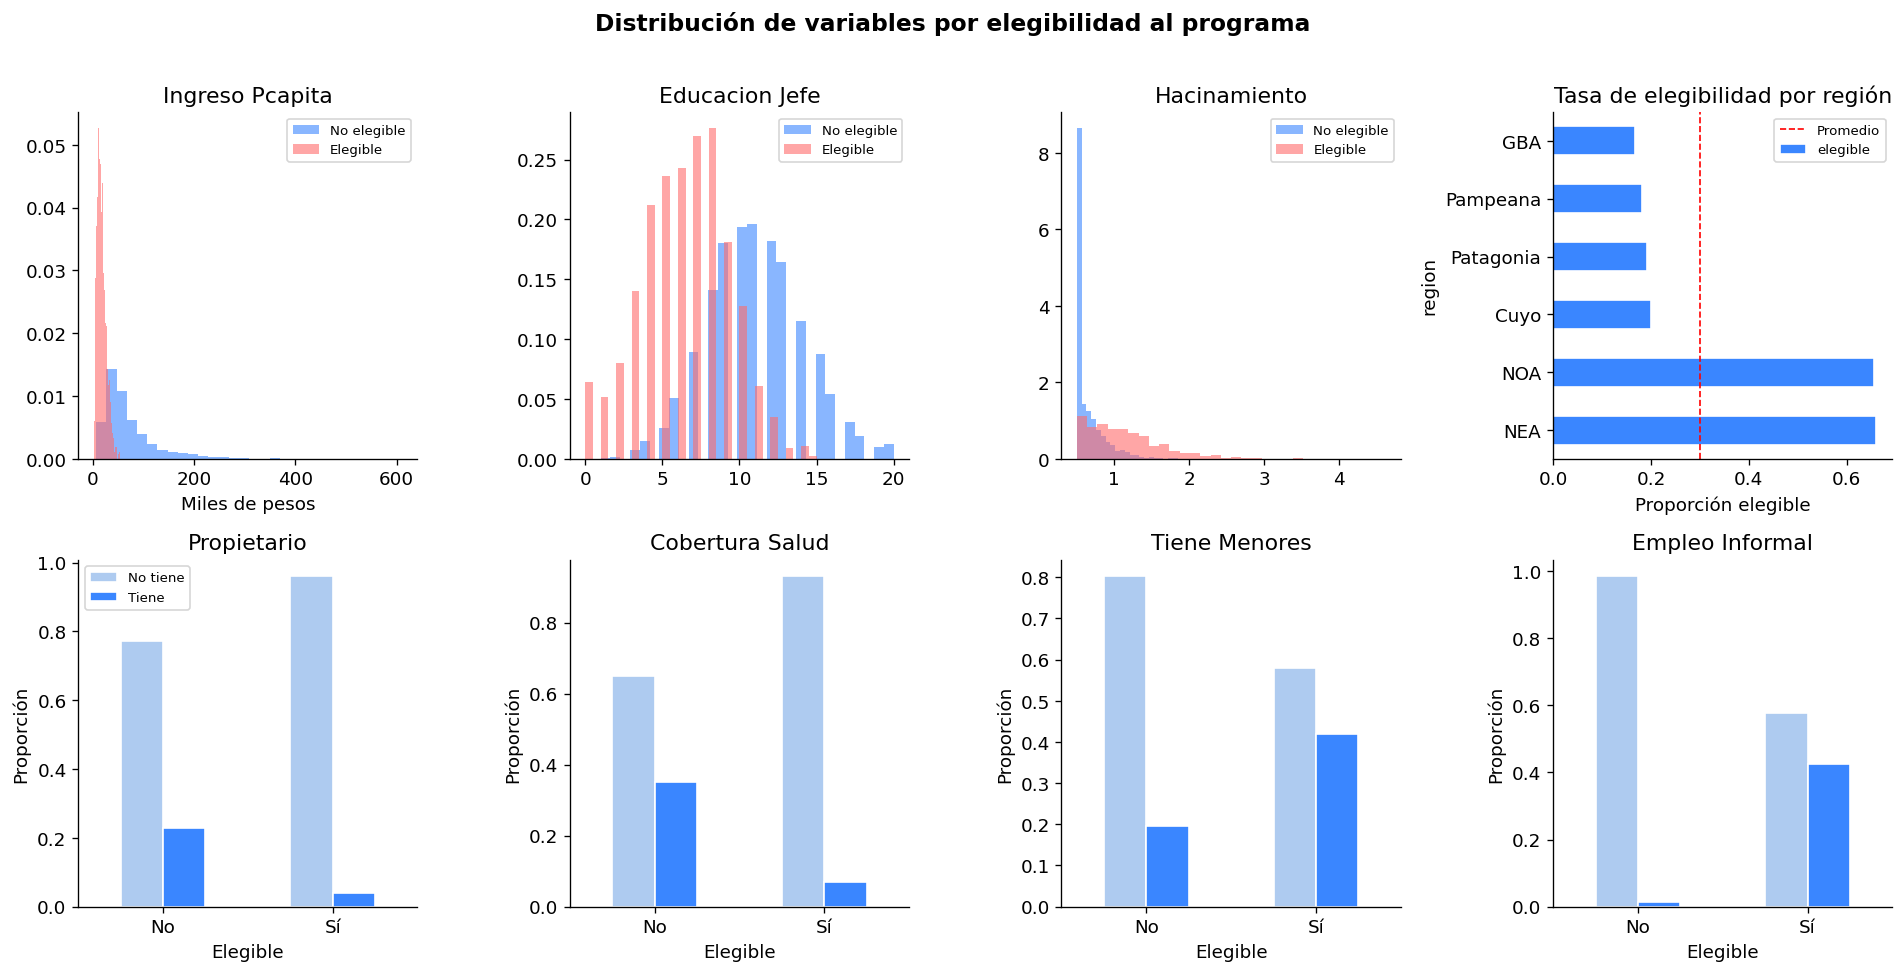

El ingreso per cápita y el nivel educativo son los predictores más discriminantes.


In [4]:
variables_continuas = ['ingreso_pcapita', 'educacion_jefe', 'hacinamiento']
variables_binarias  = ['propietario', 'cobertura_salud', 'tiene_menores', 'empleo_informal']
colores = ['#3A86FF', '#FF6B6B']
etiquetas = ['No elegible', 'Elegible']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución de variables por elegibilidad al programa', fontsize=14, fontweight='bold', y=1.01)

# Fila 1: variables continuas
for i, var in enumerate(variables_continuas):
    ax = axes[0, i]
    for val, label, color in zip([0, 1], etiquetas, colores):
        subset = df[df['elegible'] == val][var]
        if var == 'ingreso_pcapita':
            subset = subset / 1000  # en miles
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(var.replace('_', ' ').title())
    ax.legend(fontsize=8)
    if var == 'ingreso_pcapita':
        ax.set_xlabel('Miles de pesos')

# Región (cuarto panel de fila 1)
ax = axes[0, 3]
region_elegible = df.groupby('region')['elegible'].mean().sort_values(ascending=False)
region_elegible.plot(kind='barh', ax=ax, color='#3A86FF', edgecolor='white')
ax.set_title('Tasa de elegibilidad por región')
ax.set_xlabel('Proporción elegible')
ax.axvline(df['elegible'].mean(), color='red', linestyle='--', linewidth=1, label='Promedio')
ax.legend(fontsize=8)

# Fila 2: variables binarias
for i, var in enumerate(variables_binarias):
    ax = axes[1, i]
    ct = df.groupby(['elegible', var]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0)
    ct_pct.plot(kind='bar', ax=ax, color=['#AECBF0', '#3A86FF'], edgecolor='white', legend=(i==0))
    ax.set_title(var.replace('_', ' ').title())
    ax.set_xlabel('Elegible')
    ax.set_xticklabels(['No', 'Sí'], rotation=0)
    ax.set_ylabel('Proporción')
    if i == 0:
        ax.legend(['No tiene', 'Tiene'], fontsize=8)

plt.tight_layout()
plt.savefig('eda_targeting.png', bbox_inches='tight', dpi=120)
plt.show()
print('El ingreso per cápita y el nivel educativo son los predictores más discriminantes.')

---

## 4. Modelo 1: Regresión Logística

La regresión logística es el punto de partida natural para problemas de clasificación binaria. Su principal ventaja es la **interpretabilidad**: los coeficientes indican la dirección y magnitud del efecto de cada variable sobre la probabilidad de elegibilidad.

### Preparación de los datos

In [5]:
# Codificar región con dummies
df_model = pd.get_dummies(df, columns=['region'], drop_first=True)

# Variables predictoras
feature_cols = [
    'ingreso_pcapita', 'educacion_jefe', 'propietario',
    'hacinamiento', 'cobertura_salud', 'tiene_menores',
    'empleo_informal'
] + [c for c in df_model.columns if c.startswith('region_')]

X = df_model[feature_cols]
y = df_model['elegible']

# División train/test estratificada (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarización
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} hogares | Test: {X_test.shape[0]:,} hogares')
print(f'Tasa de elegibles en train: {y_train.mean():.1%} | en test: {y_test.mean():.1%}')

Train: 4,000 hogares | Test: 1,000 hogares
Tasa de elegibles en train: 30.0% | en test: 30.0%


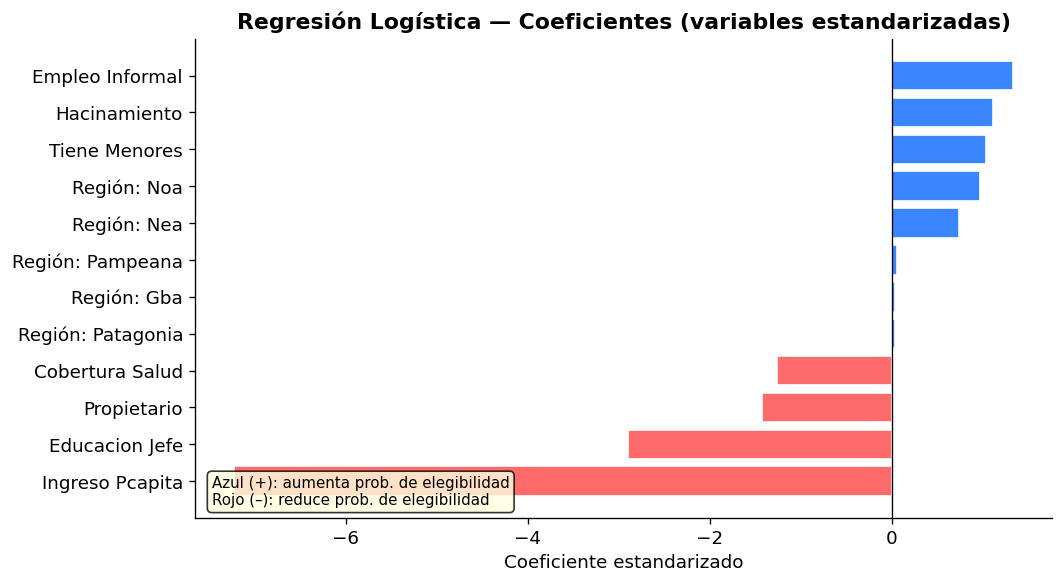

In [6]:
# Ajustar modelo
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc, y_train)

# Coeficientes
coef_df = pd.DataFrame({
    'variable': feature_cols,
    'coeficiente': log_reg.coef_[0]
}).sort_values('coeficiente')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#FF6B6B' if c < 0 else '#3A86FF' for c in coef_df['coeficiente']]
ax.barh(coef_df['variable'], coef_df['coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente estandarizado')
ax.set_title('Regresión Logística — Coeficientes (variables estandarizadas)', fontweight='bold')
ax.set_yticklabels([v.replace('region_', 'Región: ').replace('_', ' ').title() 
                    for v in coef_df['variable']])

# Anotación interpretativa
ax.text(0.02, 0.02, 'Azul (+): aumenta prob. de elegibilidad\nRojo (–): reduce prob. de elegibilidad',
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('coefs_logistica.png', bbox_inches='tight', dpi=120)
plt.show()

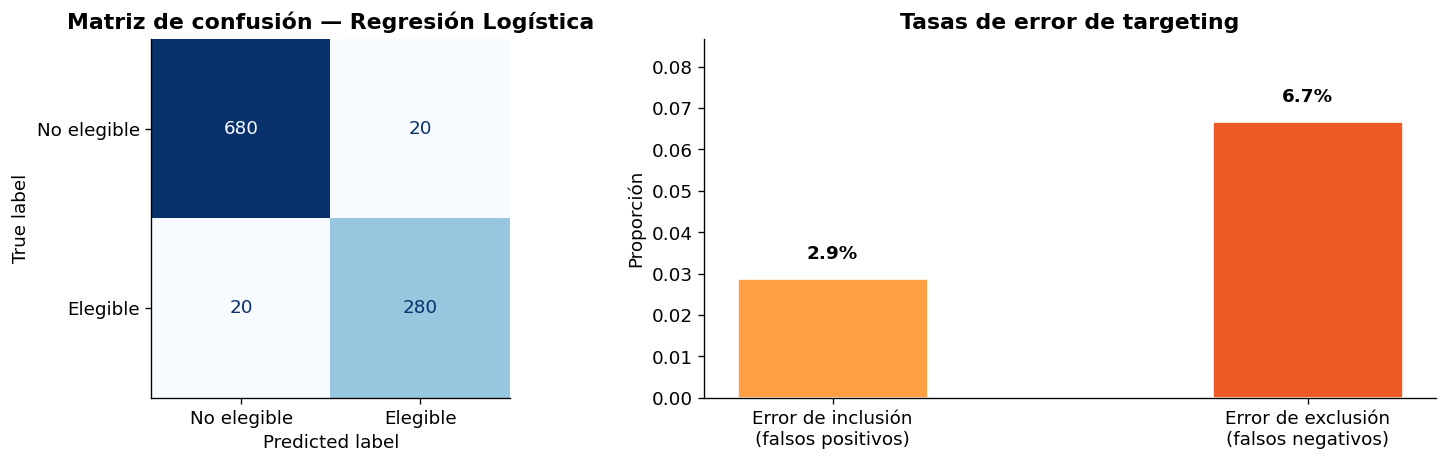


=== Reporte de clasificación — Regresión Logística ===
              precision    recall  f1-score   support

 No elegible       0.97      0.97      0.97       700
    Elegible       0.93      0.93      0.93       300

    accuracy                           0.96      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.96      0.96      0.96      1000

AUC-ROC: 0.993

--- Errores de targeting ---
Error de inclusión (hogares no elegibles que reciben el beneficio): 2.9%
Error de exclusión (hogares elegibles que NO reciben el beneficio): 6.7%


In [7]:
# Predicciones
y_pred_lr = log_reg.predict(X_test_sc)
y_proba_lr = log_reg.predict_proba(X_test_sc)[:, 1]

# --- Matriz de confusión ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No elegible', 'Elegible'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión — Regresión Logística', fontweight='bold')

# --- Reporte y tasas de error de targeting ---
tn, fp, fn, tp = cm.ravel()
tasa_inclusion  = fp / (fp + tn)  # Falsos positivos / Total no elegibles
tasa_exclusion  = fn / (fn + tp)  # Falsos negativos / Total elegibles

categorias = ['Error de inclusión\n(falsos positivos)', 'Error de exclusión\n(falsos negativos)']
tasas = [tasa_inclusion, tasa_exclusion]
colores_err = ['#FF9F43', '#EE5A24']
axes[1].bar(categorias, tasas, color=colores_err, edgecolor='white', width=0.4)
for i, (cat, t) in enumerate(zip(categorias, tasas)):
    axes[1].text(i, t + 0.005, f'{t:.1%}', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(tasas) * 1.3)
axes[1].set_title('Tasas de error de targeting', fontweight='bold')
axes[1].set_ylabel('Proporción')

plt.tight_layout()
plt.savefig('cm_logistica.png', bbox_inches='tight', dpi=120)
plt.show()

print('\n=== Reporte de clasificación — Regresión Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=['No elegible', 'Elegible']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_lr):.3f}')
print(f'\n--- Errores de targeting ---')
print(f'Error de inclusión (hogares no elegibles que reciben el beneficio): {tasa_inclusion:.1%}')
print(f'Error de exclusión (hogares elegibles que NO reciben el beneficio): {tasa_exclusion:.1%}')

### Interpretación de errores de targeting

- El **error de inclusión** indica qué proporción de hogares no vulnerables estarían recibiendo el beneficio indebidamente. Desde el punto de vista fiscal, este error eleva el costo del programa.

- El **error de exclusión** indica qué proporción de hogares que deberían recibir el beneficio quedan fuera. Este es el error de equidad: los más vulnerables quedan sin cobertura.

> En la AUH y programas similares, el umbral estándar de 0.5 puede no ser el óptimo. Veremos más adelante cómo ajustarlo.

---

## 5. Modelo 2: Random Forest

El Random Forest es un método de ensemble que construye múltiples árboles de decisión sobre subconjuntos aleatorios de datos y variables. Suele tener mejor rendimiento que la regresión logística cuando hay relaciones no lineales entre variables, pero **es menos interpretable en términos de coeficientes**.

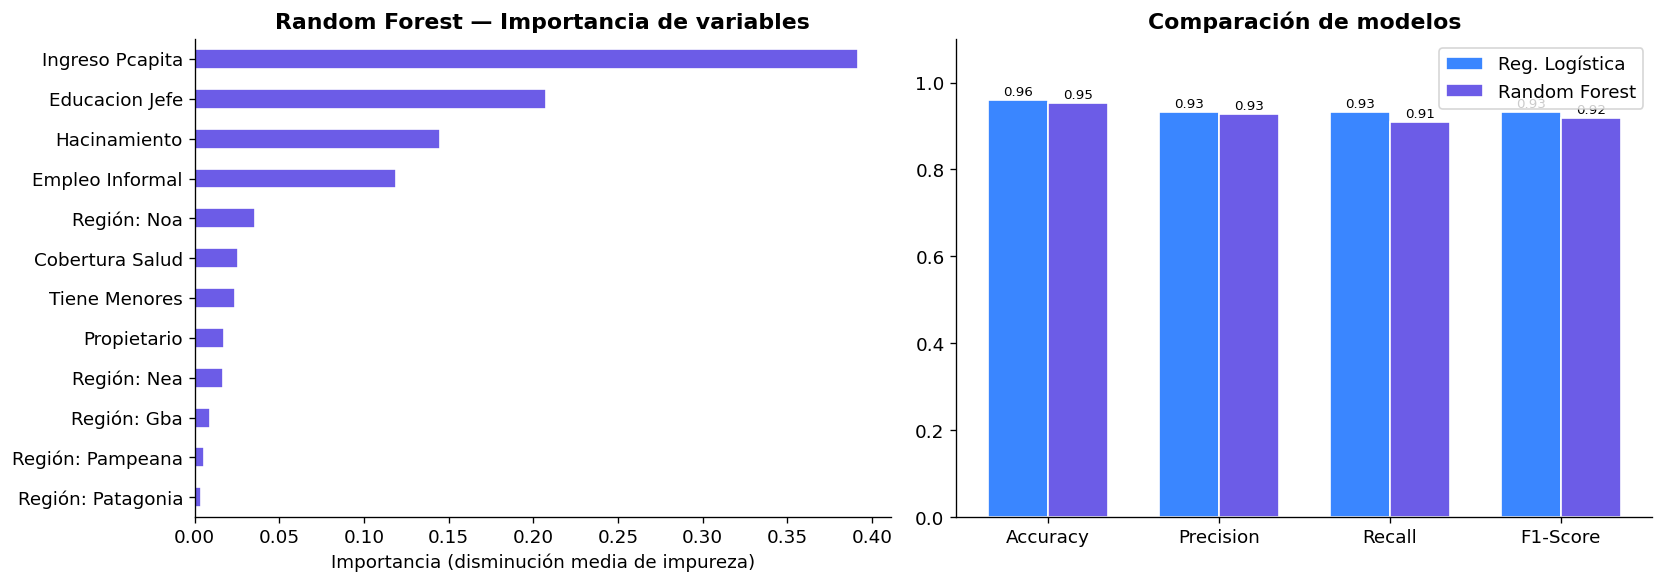

=== Reporte — Random Forest ===
              precision    recall  f1-score   support

 No elegible       0.96      0.97      0.97       700
    Elegible       0.93      0.91      0.92       300

    accuracy                           0.95      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.991
Error de inclusión:  3.0%
Error de exclusión:  9.0%


In [8]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # Random Forest no requiere estandarización

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Importancia de variables
importancias = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
labels_limpios = [v.replace('region_', 'Región: ').replace('_', ' ').title() for v in importancias.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Importancia de variables
importancias.plot(kind='barh', ax=axes[0], color='#6C5CE7', edgecolor='white')
axes[0].set_yticklabels(labels_limpios)
axes[0].set_xlabel('Importancia (disminución media de impureza)')
axes[0].set_title('Random Forest — Importancia de variables', fontweight='bold')

# Comparación accuracy/precision/recall
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores_lr = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]
valores_rf = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metricas))
width = 0.35
axes[1].bar(x - width/2, valores_lr, width, label='Reg. Logística', color='#3A86FF', edgecolor='white')
axes[1].bar(x + width/2, valores_rf, width, label='Random Forest',  color='#6C5CE7', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metricas)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Comparación de modelos', fontweight='bold')
axes[1].legend()
for rect in axes[1].patches:
    h = rect.get_height()
    axes[1].text(rect.get_x() + rect.get_width()/2., h + 0.01, f'{h:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('rf_comparacion.png', bbox_inches='tight', dpi=120)
plt.show()

cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()
print('=== Reporte — Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['No elegible', 'Elegible']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba_rf):.3f}')
print(f'Error de inclusión:  {fp_rf/(fp_rf+tn_rf):.1%}')
print(f'Error de exclusión:  {fn_rf/(fn_rf+tp_rf):.1%}')

---

## 6. Análisis de umbral: el trade-off entre errores de targeting

Hasta ahora, ambos modelos usaron el umbral por defecto de 0.5: un hogar es clasificado como elegible si la probabilidad predicha supera el 50%. Pero en política pública este umbral rara vez es el óptimo.

- **Umbral más alto (ej: 0.7):** El modelo solo asigna elegibilidad a hogares con alta confianza. Reduce los errores de inclusión pero aumenta los de exclusión.
- **Umbral más bajo (ej: 0.3):** El modelo amplía la elegibilidad. Reduce los errores de exclusión pero incluye más hogares no vulnerables.

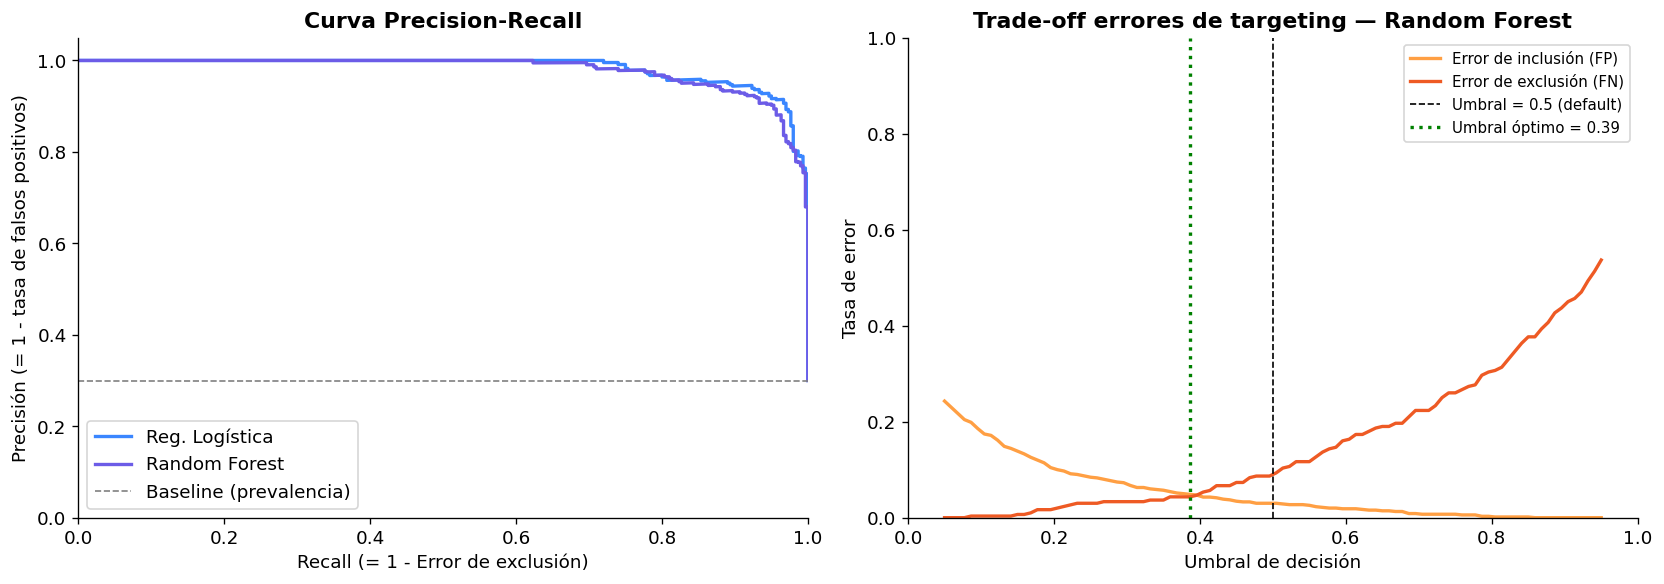

Umbral que minimiza la suma de errores de inclusión y exclusión: 0.39


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Curva Precision-Recall ---
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_proba_lr)
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)

axes[0].plot(recall_lr, precision_lr, color='#3A86FF', lw=2, label='Reg. Logística')
axes[0].plot(recall_rf, precision_rf, color='#6C5CE7', lw=2, label='Random Forest')
axes[0].axhline(y_test.mean(), color='gray', linestyle='--', lw=1, label='Baseline (prevalencia)')
axes[0].set_xlabel('Recall (= 1 - Error de exclusión)')
axes[0].set_ylabel('Precisión (= 1 - tasa de falsos positivos)')
axes[0].set_title('Curva Precision-Recall', fontweight='bold')
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# --- Panel 2: Trade-off inclusión/exclusión por umbral (Random Forest) ---
umbrales = np.linspace(0.05, 0.95, 100)
incl_errors = []
excl_errors = []

for u in umbrales:
    pred_u = (y_proba_rf >= u).astype(int)
    cm_u = confusion_matrix(y_test, pred_u)
    if cm_u.shape == (2, 2):
        tn_u, fp_u, fn_u, tp_u = cm_u.ravel()
        incl_errors.append(fp_u / (fp_u + tn_u) if (fp_u + tn_u) > 0 else 0)
        excl_errors.append(fn_u / (fn_u + tp_u) if (fn_u + tp_u) > 0 else 0)
    else:
        incl_errors.append(np.nan)
        excl_errors.append(np.nan)

axes[1].plot(umbrales, incl_errors, color='#FF9F43', lw=2, label='Error de inclusión (FP)')
axes[1].plot(umbrales, excl_errors, color='#EE5A24', lw=2, label='Error de exclusión (FN)')
axes[1].axvline(0.5, color='black', linestyle='--', lw=1, label='Umbral = 0.5 (default)')

# Umbral óptimo: minimiza la suma de ambos errores
suma_errores = [i + e for i, e in zip(incl_errors, excl_errors)]
umbral_optimo = umbrales[np.nanargmin(suma_errores)]
axes[1].axvline(umbral_optimo, color='green', linestyle=':', lw=2, 
                label=f'Umbral óptimo = {umbral_optimo:.2f}')

axes[1].set_xlabel('Umbral de decisión')
axes[1].set_ylabel('Tasa de error')
axes[1].set_title('Trade-off errores de targeting — Random Forest', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Umbral que minimiza la suma de errores de inclusión y exclusión: {umbral_optimo:.2f}')

In [10]:
# Evaluación con umbral óptimo
y_pred_optimo = (y_proba_rf >= umbral_optimo).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_optimo)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

print(f'=== Random Forest con umbral óptimo ({umbral_optimo:.2f}) ===')
print(f'Error de inclusión:  {fp_o/(fp_o+tn_o):.1%}  (antes: {fp_rf/(fp_rf+tn_rf):.1%})')
print(f'Error de exclusión:  {fn_o/(fn_o+tp_o):.1%}  (antes: {fn_rf/(fn_rf+tp_rf):.1%})')
print(f'\nPresupuesto relativo (beneficiarios asignados):')
print(f'  Con umbral 0.50: {y_pred_rf.sum():,} hogares ({y_pred_rf.mean():.1%})')
print(f'  Con umbral {umbral_optimo:.2f}: {y_pred_optimo.sum():,} hogares ({y_pred_optimo.mean():.1%})')

=== Random Forest con umbral óptimo (0.39) ===
Error de inclusión:  4.9%  (antes: 3.0%)
Error de exclusión:  4.3%  (antes: 9.0%)

Presupuesto relativo (beneficiarios asignados):
  Con umbral 0.50: 294 hogares (29.4%)
  Con umbral 0.39: 321 hogares (32.1%)


---

## 7. Conclusión de política: ¿qué modelo recomendarías?

### Síntesis comparativa

In [11]:
resumen = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest (umbral 0.5)', f'Random Forest (umbral {umbral_optimo:.2f})'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_rf)
    ],
    'Error inclusión': [
        fp/(fp+tn), fp_rf/(fp_rf+tn_rf), fp_o/(fp_o+tn_o)
    ],
    'Error exclusión': [
        fn/(fn+tp), fn_rf/(fn_rf+tp_rf), fn_o/(fn_o+tp_o)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_optimo)
    ]
})
resumen = resumen.set_index('Modelo')
resumen.style.format('{:.3f}').highlight_min(color='#d4edda').highlight_max(color='#f8d7da')

,AUC-ROC,Error inclusión,Error exclusión,F1-Score
Modelo,,,,
Regresión Logística,0.993,0.029,0.067,0.933
Random Forest (umbral 0.5),0.991,0.030,0.090,0.919
Random Forest (umbral 0.39),0.991,0.049,0.043,0.924


### Recomendación

**Para la mayoría de los programas sociales con presupuesto acotado:**

1. **Random Forest con umbral ajustado** ofrece el mejor rendimiento predictivo (AUC-ROC superior) y permite calibrar el trade-off inclusión/exclusión según las prioridades de política.

2. **Sin embargo**, la **Regresión Logística** tiene ventajas no técnicas cruciales en política pública:
   - Es **auditable**: funcionarios y beneficiarios pueden entender por qué se tomó la decisión.
   - Es **judicializable**: se puede defender ante reclamos administrativos.
   - Es más **robusta a overfitting** cuando el dataset es pequeño o tiene variables con baja calidad.

3. **Recomendación práctica:** Usar Random Forest para *priorizar* el orden de atención (scoring), pero Regresión Logística para la *regla de elegibilidad* formal publicada en el boletín oficial.

4. **Umbral:** Si el programa tiene restricción presupuestaria fija, el umbral debe ajustarse para respetar la restricción. Si el mandato es cobertura universal de vulnerables, el umbral debe minimizar el error de exclusión aunque ello implique mayor costo.

> **Nota ética:** Los modelos de ML pueden perpetuar o amplificar sesgos históricos. Si los datos de entrenamiento reflejan un programa previo con errores de exclusión sistemáticos para ciertos grupos (ej: pueblos originarios, migrantes), el modelo aprenderá ese sesgo. Siempre analizar las métricas desagregadas por subgrupos.

---

## Ejercicios

### Ejercicio 1 — Ajuste de umbral con restricción presupuestaria

Supongamos que el programa tiene presupuesto para atender exactamente al **25% de los hogares** (en lugar del 30% que es la tasa real de elegibles). 

a) Usando las probabilidades del Random Forest, encontrá el umbral que clasifica exactamente al 25% de los hogares del test set como elegibles.  
b) Calculá los errores de inclusión y exclusión con ese umbral.  
c) ¿Qué grupo etario o región resulta más perjudicado por la restricción presupuestaria? (sugerencia: analizá los falsos negativos según las variables del dataset original).

```python
# Tu código aquí
# Pista: usá np.percentile(y_proba_rf, 75) como umbral inicial
```

### Ejercicio 2 — Curva ROC y comparación visual

a) Graficar las curvas ROC de ambos modelos en el mismo plot.  
b) Sombrear el área bajo la curva (AUC) para cada modelo.  
c) ¿En qué región de la curva (baja tasa de FP vs alta tasa de FP) se diferencia más el Random Forest de la Regresión Logística? ¿Qué implicancia tiene esto para la política?

```python
from sklearn.metrics import roc_curve
# Tu código aquí
```

### Ejercicio 3 — Análisis de equidad (fairness)

a) Calculá las tasas de error de exclusión **por región** para el Random Forest con umbral 0.5.  
b) ¿Hay regiones para las cuales el modelo excluye más hogares elegibles que otras?  
c) Si el error de exclusión en una región es significativamente mayor al promedio, ¿qué medidas de política podrían compensarlo?

```python
# Pista: merge de X_test con y_test y y_pred_rf usando los índices originales
# Tu código aquí
```